# Exercise 5 - Training Your Own Skip-gram

---

Names: Jullian Bilan, Kyla Elijah Ramiro

CYS: BSCS 3-A AI

---

## Step 1: Load Wikipedia Article as Corpus

This section sets imports, configuration, and article-fetching logic.

In [45]:
import re
import math
import json
import random
from collections import Counter
from typing import List, Tuple, Dict

import numpy as np
import scipy.linalg as sp_linalg

# Gensim 4.x expects scipy.linalg.triu in some environments.
# Newer SciPy builds may not expose it, so map to numpy.triu.
if not hasattr(sp_linalg, "triu"):
    sp_linalg.triu = np.triu

import requests
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity


# Paste the Wikipedia link you want to use here.
WIKI_URL = "https://en.wikipedia.org/wiki/Adventure_Time"
RANDOM_SEED = 42

## Step 2: Preprocess the Text

This part defines text cleaning, tokenization, and sentence preprocessing.

In [46]:
def ensure_nltk():
    resources = ["punkt", "punkt_tab"]
    for r in resources:
        try:
            nltk.data.find(f"tokenizers/{r}")
        except (LookupError, OSError):
            nltk.download(r)


def fetch_wikipedia_article(url: str) -> str:
    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; SGNS-Gundam-Training/1.0)"
    }
    resp = requests.get(url, headers=headers, timeout=30)
    resp.raise_for_status()

    soup = BeautifulSoup(resp.text, "html.parser")

    content_div = soup.find("div", {"id": "mw-content-text"})
    if content_div is None:
        raise ValueError("Could not find Wikipedia article content.")

    paragraphs = content_div.find_all(["p", "li"])
    text_blocks = []

    for p in paragraphs:
        txt = p.get_text(" ", strip=True)
        if txt:
            text_blocks.append(txt)

    text = "\n".join(text_blocks)
    text = re.sub(r"\[[0-9]+\]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

## Step 3: Train Skip-gram with Negative Sampling (Word2Vec)

This part defines `train_sgns(...)` with Word2Vec training parameters.

In [47]:
def preprocess_text(text: str) -> List[List[str]]:
    sentences = sent_tokenize(text)

    processed = []
    for sent in sentences:
        sent = sent.lower()
        sent = re.sub(r"[^a-z0-9\-\s]", " ", sent)
        sent = re.sub(r"\s+", " ", sent).strip()
        if not sent:
            continue

        tokens = word_tokenize(sent)

        cleaned = []
        for tok in tokens:
            tok = tok.strip("-")
            if not tok:
                continue
            if tok.isdigit():
                continue
            if len(tok) < 2:
                continue
            cleaned.append(tok)

        if len(cleaned) >= 3:
            processed.append(cleaned)

    return processed


def corpus_stats(sentences: List[List[str]]) -> Dict[str, int]:
    flat = [w for s in sentences for w in s]
    vocab = set(flat)
    return {
        "num_sentences": len(sentences),
        "num_tokens": len(flat),
        "vocab_size": len(vocab),
    }


def train_sgns(sentences: List[List[str]]) -> Word2Vec:
    model = Word2Vec(
        sentences=sentences,
        vector_size=100,
        window=5,
        min_count=1,
        workers=4,
        sg=1,
        negative=10,
        epochs=200,
        sample=1e-3,
        alpha=0.025,
        min_alpha=0.0007,
        seed=RANDOM_SEED,
    )
    return model

## Step 4: Evaluate Embeddings Using a Test Set

This part defines relatedness and analogy evaluation helpers.

In [48]:
def has_word(model: Word2Vec, word: str) -> bool:
    return word in model.wv.key_to_index


def cosine(model: Word2Vec, w1: str, w2: str) -> float:
    v1 = model.wv[w1].reshape(1, -1)
    v2 = model.wv[w2].reshape(1, -1)
    return float(cosine_similarity(v1, v2)[0][0])


def evaluate_relatedness(model: Word2Vec, test_pairs: List[Tuple[str, str, float]]):
    covered = []
    for w1, w2, score in test_pairs:
        if has_word(model, w1) and has_word(model, w2):
            sim = cosine(model, w1, w2)
            covered.append((w1, w2, score, sim))

    return {
        "covered_items": covered,
        "coverage": len(covered),
        "total": len(test_pairs),
    }


def evaluate_analogies(model: Word2Vec, analogies: List[Tuple[str, str, str, str]]):
    covered = 0
    correct = 0
    details = []

    for a, b, c, d in analogies:
        if all(has_word(model, w) for w in [a, b, c, d]):
            covered += 1
            try:
                preds = model.wv.most_similar(positive=[b, c], negative=[a], topn=5)
                predicted_words = [w for w, _ in preds]
                hit = d in predicted_words
                correct += int(hit)
                details.append({
                    "analogy": f"{a}:{b}::{c}:?",
                    "expected": d,
                    "predictions": predicted_words,
                    "correct_in_top5": hit
                })
            except KeyError:
                pass

    accuracy = correct / covered if covered else float("nan")
    return {
        "coverage": covered,
        "total": len(analogies),
        "accuracy_top5": accuracy,
        "details": details
    }


def print_top_neighbors(model: Word2Vec, words: List[str], topn: int = 8):
    print("\n=== Nearest Neighbors ===")
    for word in words:
        if has_word(model, word):
            neighbors = model.wv.most_similar(word, topn=topn)
            print(f"\n{word}:")
            for neigh, score in neighbors:
                print(f"  {neigh:20s} {score:.4f}")
        else:
                print(f"\n{word}: [OOV]")

## Step 5: Report Nearest Neighbors, Similarity Scores, and Test-Set Performance

This execution block trains, evaluates, and prints the report outputs.

In [49]:
def main():
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    ensure_nltk()

    print("Downloading Wikipedia article...")
    raw_text = fetch_wikipedia_article(WIKI_URL)

    print("Preprocessing text...")
    sentences = preprocess_text(raw_text)
    stats = corpus_stats(sentences)

    print("\n=== Corpus Stats ===")
    for k, v in stats.items():
        print(f"{k}: {v}")

    print("\nTraining Skip-gram with Negative Sampling...")
    model = train_sgns(sentences)

    print("\nVocabulary size learned:", len(model.wv))

    probe_words = [
        "finn", "jake", "bubblegum", "marceline",
        "bmo", "ice", "king", "candy", "sword", "hero"
    ]
    print_top_neighbors(model, probe_words, topn=8)


    # Domain-specific relatedness test set
    # Higher score means should be more semantically related
    relatedness_test = [
        ("finn",       "jake",       0.95),
        ("ice",        "king",       0.95),
        ("princess",  "bubblegum",   0.92),
        ("marceline",  "vampire",    0.90),
        ("finn",       "hero",       0.88),
        ("jake",       "dog",        0.88),
        ("bubblegum",  "candy",   0.85),
        ("bmo",        "game",       0.80),
        ("sword",      "finn",       0.75),
        ("candy",      "kingdom",    0.75),
        ("finn",       "candy",      0.10),
        ("bmo",        "king",       0.08),
        ("jake",       "crown",      0.05),
        ("marceline",  "kingdom",    0.15),
    ]
    rel_results = evaluate_relatedness(model, relatedness_test)
    print("\n=== Relatedness Test Set ===")
    print(f"Coverage: {rel_results['coverage']}/{rel_results['total']}")
    for w1, w2, gold, pred in rel_results["covered_items"]:
        print(f"{w1:10s} - {w2:10s} | gold={gold:.2f} pred={pred:.4f}")

    # Small analogy-style test set
    # These are intentionally tiny and corpus-dependent because a single article is a small dataset.
    # Change this based on what you find in the article and what words are present in the model.
    analogy_test = [
        # A is to B as C is to D
        ("finn",      "hero",     "marceline", "vampire"),   # finn:hero :: marceline:vampire
        ("jake",      "dog",      "finn",      "human"),     # jake:dog :: finn:human
        ("ice",       "king",     "princess", "bubblegum"),  # ice:king :: princess:bubblegum
        ("candy",     "kingdom",  "ice",       "king"),      # candy:kingdom :: ice:king
    ]
    analogy_results = evaluate_analogies(model, analogy_test)
    print("\n=== Analogy Test Set ===")
    print(f"Coverage: {analogy_results['coverage']}/{analogy_results['total']}")
    print(f"Top-5 accuracy: {analogy_results['accuracy_top5']}")
    for item in analogy_results["details"]:
        print(json.dumps(item, ensure_ascii=False))

    # Change these pairs based on what you expect to be related/unrelated in the article and what words are in the model.
    print("\n=== Direct Similarity Checks ===")
    check_pairs = [
        ("finn",      "jake"),      
        ("ice",       "king"),       
        ("princess", "bubblegum"),   
        ("finn",      "candy"),      # unrelated 
    ]
    for w1, w2 in check_pairs:
        if has_word(model, w1) and has_word(model, w2):
            print(f"{w1:10s} <-> {w2:10s}: {cosine(model, w1, w2):.4f}")
        else:
            print(f"{w1:10s} <-> {w2:10s}: OOV")

    model.save("exercise_5_skipgram_sgns.model")
    print("\nSaved model to: exercise_5_skipgram_sgns.model")
    print("\nDone.")

main()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Preprocessing text...

=== Corpus Stats ===
num_sentences: 1289
num_tokens: 16077
vocab_size: 3303

Training Skip-gram with Negative Sampling...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'



Vocabulary size learned: 3303

=== Nearest Neighbors ===

finn:
  jake                 0.5921
  adventuring          0.5904
  human                0.5858
  shown                0.5727
  promoting            0.5484
  princesses           0.5474
  interact             0.5364
  thai                 0.5323

jake:
  adventuring          0.5935
  finn                 0.5921
  investigations       0.5855
  shown                0.5789
  appears              0.5704
  promoting            0.5582
  splat                0.5579
  interact             0.5491

bubblegum:
  princess             0.7427
  date                 0.6679
  spaghetti-supper     0.6672
  confirms             0.6225
  options              0.6079
  zeroing              0.6003
  mock                 0.6003
  intervened           0.5990

marceline:
  closet               0.6865
  adrift               0.6704
  correct              0.6598
  confirms             0.6404
  emphasis             0.6376
  options              0.6373
  mo

## Update 1: Retrain with Window Size = 10

This section runs the required OLD (window=5) and NEW (window=10) comparison.

In [50]:
# Helper for Activity Update 1: run one experiment and return compact metrics
def run_experiment(window_size: int):
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    ensure_nltk()

    raw_text = fetch_wikipedia_article(WIKI_URL)
    sentences = preprocess_text(raw_text)

    model = Word2Vec(
        sentences=sentences,
        vector_size=100,
        window=window_size,
        min_count=1,
        workers=4,
        sg=1,
        negative=10,
        epochs=200,
        sample=1e-3,
        alpha=0.025,
        min_alpha=0.0007,
        seed=RANDOM_SEED,
    )

    relatedness_test = [
        ("finn",       "jake",       0.95),
        ("ice",        "king",       0.95),
        ("princess",  "bubblegum",   0.92),
        ("marceline",  "vampire",    0.90),
        ("finn",       "hero",       0.88),
        ("jake",       "dog",        0.88),
        ("bubblegum",  "candy",   0.85),
        ("bmo",        "game",       0.80),
        ("sword",      "finn",       0.75),
        ("candy",      "kingdom",    0.75),
        ("finn",       "candy",      0.10),
        ("bmo",        "king",       0.08),
        ("jake",       "crown",      0.05),
        ("marceline",  "kingdom",    0.15),
    ]
    
    analogy_test = [
        ("finn", "hero", "marceline", "vampire"),
        ("jake", "dog", "finn", "human"),
        ("ice", "king", "princess", "bubblegum"),
        ("candy", "kingdom", "ice", "king"),
    ]

    rel = evaluate_relatedness(model, relatedness_test)
    ana = evaluate_analogies(model, analogy_test)

    pair_scores = {}
    for w1, w2 in [("finn", "jake"), ("ice", "king"), ("princess", "bubblegum"), ("finn", "candy")]:
        if has_word(model, w1) and has_word(model, w2):
            pair_scores[f"{w1}-{w2}"] = cosine(model, w1, w2)
        else:
            pair_scores[f"{w1}-{w2}"] = None

    metrics = {
        "window": window_size,
        "vocab_size": len(model.wv),
        "relatedness_coverage": f"{rel['coverage']}/{rel['total']}",
        "analogy_coverage": f"{ana['coverage']}/{ana['total']}",
        "analogy_top5_accuracy": ana["accuracy_top5"],
        "pair_scores": pair_scores,
    }

    return model, metrics

### Comparison: Old vs New Model Results

In [51]:
# Activity Update 1 - OLD (window = 5)
model_old, old_metrics = run_experiment(window_size=5)
print("OLD metrics:")
print(json.dumps(old_metrics, indent=2))

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


OLD metrics:
{
  "window": 5,
  "vocab_size": 3303,
  "relatedness_coverage": "12/14",
  "analogy_coverage": "4/4",
  "analogy_top5_accuracy": 0.75,
  "pair_scores": {
    "finn-jake": 0.5899060964584351,
    "ice-king": 0.8191311359405518,
    "princess-bubblegum": 0.728891134262085,
    "finn-candy": 0.41583454608917236
  }
}


In [52]:
# Activity Update 1 - NEW (window = 10)
model_new, new_metrics = run_experiment(window_size=10)
print("NEW metrics:")
print(json.dumps(new_metrics, indent=2))

comparison_summary = {
    "OLD_window_5": old_metrics,
    "NEW_window_10": new_metrics,
}

print("\nOLD vs NEW summary:")
print(json.dumps(comparison_summary, indent=2))

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


NEW metrics:
{
  "window": 10,
  "vocab_size": 3303,
  "relatedness_coverage": "12/14",
  "analogy_coverage": "4/4",
  "analogy_top5_accuracy": 0.75,
  "pair_scores": {
    "finn-jake": 0.665040135383606,
    "ice-king": 0.812548041343689,
    "princess-bubblegum": 0.7175345420837402,
    "finn-candy": 0.3322603106498718
  }
}

OLD vs NEW summary:
{
  "OLD_window_5": {
    "window": 5,
    "vocab_size": 3303,
    "relatedness_coverage": "12/14",
    "analogy_coverage": "4/4",
    "analogy_top5_accuracy": 0.75,
    "pair_scores": {
      "finn-jake": 0.5899060964584351,
      "ice-king": 0.8191311359405518,
      "princess-bubblegum": 0.728891134262085,
      "finn-candy": 0.41583454608917236
    }
  },
  "NEW_window_10": {
    "window": 10,
    "vocab_size": 3303,
    "relatedness_coverage": "12/14",
    "analogy_coverage": "4/4",
    "analogy_top5_accuracy": 0.75,
    "pair_scores": {
      "finn-jake": 0.665040135383606,
      "ice-king": 0.812548041343689,
      "princess-bubblegum"

## Update 2: PCA Visualization of Word Vectors

This section visualizes at least 20 known words from the trained model.

Words used for PCA (20): ['finn', 'jake', 'bubblegum', 'marceline', 'bmo', 'ice', 'king', 'candy', 'hero', 'princess', 'vampire', 'dog', 'human', 'adventure', 'time', 'kingdom', 'lich', 'evil', 'rainicorn', 'magic']


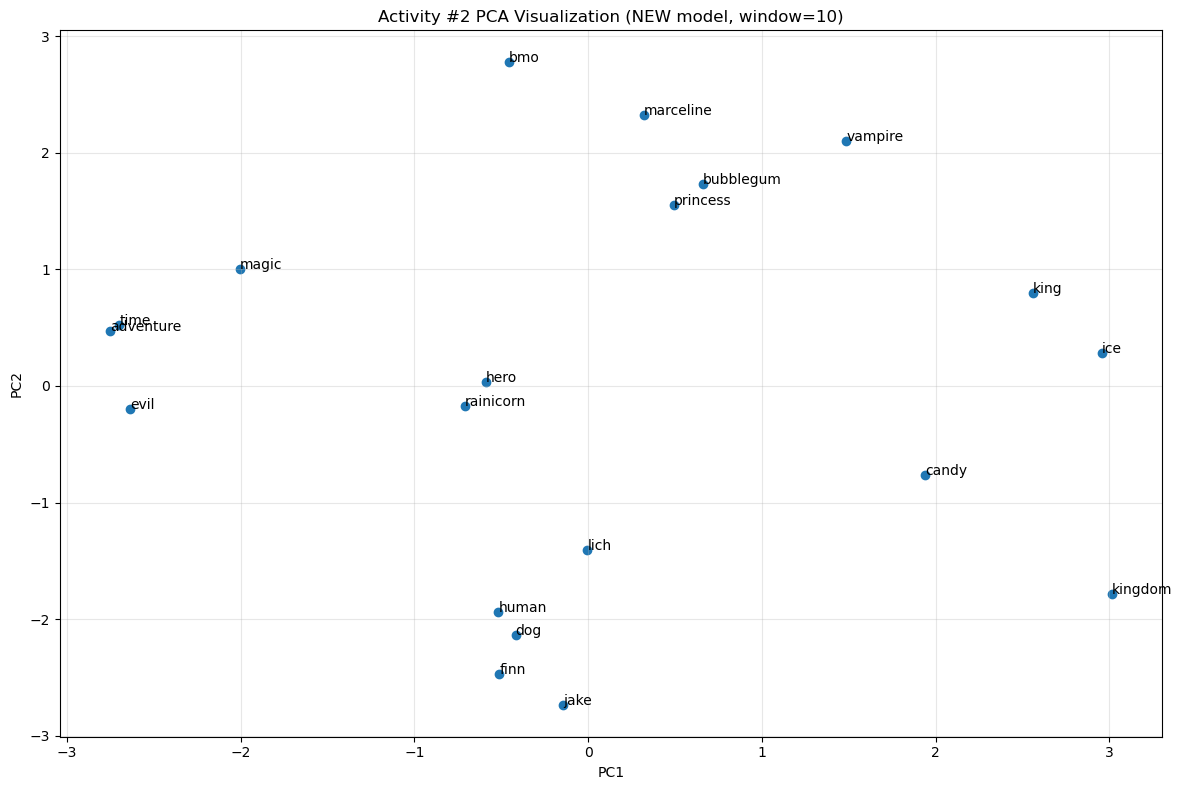

In [53]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

candidate_words = [
    "finn", "jake", "bubblegum", "marceline", "bmo", "ice", "king", "candy", "sword", "hero",
    "princess", "vampire", "dog", "human", "adventure", "time", "kingdom", "crown", "lich", "evil",
    "oo", "rainicorn", "magic", "wizard", "tree", "house", "land", "gum", "flame", "lumpy",
    "lemongrab", "gunter", "penguin", "banana", "guard", "nightosphere", "demon", "wizard", "portal", "monster",
]

known_words = [w for w in candidate_words if w in model_new.wv.key_to_index][:20]
print(f"Words used for PCA ({len(known_words)}):", known_words)

vectors = np.array([model_new.wv[w] for w in known_words])
coords = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(vectors)

plt.figure(figsize=(12, 8))
plt.scatter(coords[:, 0], coords[:, 1])
for i, word in enumerate(known_words):
    plt.annotate(word, (coords[i, 0], coords[i, 1]))

plt.title("Activity #2 PCA Visualization (NEW model, window=10)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()